In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
import random
from sklearn.decomposition import PCA
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
#SETTINGS OG HYPERPARAMETERS

#dataset
dataset = "mnist"      # "mnist" or "random" 
subset_percent = 0.1   # set to 1.0 hvis I vil bruge alt data

#graph construction
graph_construction = "knn"  # "knn" or "random"

if graph_construction == "knn":
    k = 15 
if graph_construction == "random":
    p = 0.1
negative_sampling_coeff = 5 # sample this many more negatives than positives each epoch

#initialization
initialization = "PCA" # "PCA" or "None"

#training
num_epochs = 10000
early_stopping_patience = 100
early_stopping_min_delta = 0.0

In [3]:


if dataset == "mnist":
    #Load MNIST dataset
    transform = transforms.Compose([transforms.ToTensor()])

    mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    X_full = torch.cat([mnist_train.data, mnist_test.data], dim=0).float().view(-1, 28*28) / 255.0
    y_full = torch.cat([mnist_train.targets, mnist_test.targets], dim=0)

    print("Node matrix shape:", X_full.shape)   # (n, d)
    print("Target vector shape:", y_full.shape)  # (n,)

    from sklearn.model_selection import train_test_split

    # X = features, y = labels
    # Keep fx. 30% of the full dataset, preserving class proportions
    X_subset, _, y_subset, _ = train_test_split(
        X_full, y_full,
        train_size=subset_percent,      
        stratify=y_full,           # preserves class distribution
        random_state=42
        )
    X = X_subset
    y = y_subset
    print("Subset node matrix shape:", X.shape)   # (n_subset, d)
    print("Subset target vector shape:", y.shape)  # (n_subset,)
    
    n = X.shape[0]  # number of nodes
    d = X.shape[1]  # feature dimension

if dataset == "random":
    n = 1000  # choose number of nodes
    d = 128   # choosefeature dimension
    X = torch.randn(n, d, requires_grad=True)

   
alpha = torch.tensor(0.0, requires_grad=True)

Node matrix shape: torch.Size([70000, 784])
Target vector shape: torch.Size([70000])
Subset node matrix shape: torch.Size([7000, 784])
Subset target vector shape: torch.Size([7000])


In [4]:
def random_undirected_binary_graph(n: int, d: int, p: float = 0.3, seed: int | None = None):
    """
    n: number of nodes
    d: node dimension (feature/position dimension)
    p: probability of an edge between any pair of nodes
    """
    rng = np.random.default_rng(seed)

    # Sample edges only once (upper triangle, no diagonal)
    upper = (rng.random((n, n)) < p).astype(np.uint8)
    upper = np.triu(upper, k=1)

    # Mirror to enforce undirected symmetry: A[i,j] == A[j,i]
    A = upper + upper.T

    return A

def knn_graph(X: torch.Tensor, k: int = 3):
    """
    X: (n, d) node feature matrix
    k: number of nearest neighbors to connect
    """
    n = X.shape[0]

    # Compute pairwise distances (n, n)
    dist = torch.cdist(X, X)

    # For each node, find indices of k nearest neighbors (excluding self)
    knn_indices = torch.topk(dist, k=k+1, largest=False).indices[:, 1:]

    # Create adjacency matrix
    A = torch.zeros(n, n, dtype=torch.uint8)
    for i in range(n):
        A[i, knn_indices[i]] = 1

    # Symmetrize to ensure undirected graph
    A = torch.max(A, A.T)

    return A

In [5]:
if graph_construction == "random":
    A = random_undirected_binary_graph(n, d, p=p, seed=42)
    print("Adjacency matrix:\n", A)
    print("Symmetric:", np.all(A == A.T))

if graph_construction == "knn":
    A = knn_graph(X, k=k)
    print("Adjacency matrix:\n", A)
    print("Symmetric:", torch.equal(A, A.T))

A_tensor = torch.as_tensor(A, device=device)

Adjacency matrix:
 tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)
Symmetric: True


In [6]:
n = A.shape[0]
d = 2
alpha = torch.tensor(0.0, requires_grad=True, device=device)

if initialization == "PCA":
    pca = PCA(n_components=d)
    Z_init = pca.fit_transform(X.cpu().numpy())
    Z = torch.tensor(Z_init, dtype=torch.float32, device=device, requires_grad=True)
elif initialization == "None":
    Z = (0.1 * torch.randn(n, d, device=device)).requires_grad_()



# Build unique undirected pairs (upper triangle)
i, j = torch.triu_indices(n, n, offset=1, device=device)
pair_targets = torch.as_tensor(A, dtype=torch.float32, device=device)[i, j]
pos_mask = pair_targets == 1
neg_mask = pair_targets == 0

# Index lists used for negative sampling
pos_idx = torch.where(pos_mask)[0].to(device)
neg_idx = torch.where(neg_mask)[0].to(device)
num_pos = int(pos_idx.numel())
num_neg_total = int(neg_idx.numel())
num_neg_sample = min(num_neg_total, int(negative_sampling_coeff * num_pos))

print(f"positive pairs: {num_pos}, total negative pairs: {num_neg_total}, sampled negatives/epoch: {num_neg_sample}")


optimizer = torch.optim.Adam([Z, alpha], lr=2e-3)

best_loss = float("inf")
epochs_since_improvement = 0

for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Sample negatives by index
    neg_pick = torch.randint(0, num_neg_total, (num_neg_sample,), device=Z.device)
    neg_sample_idx = neg_idx[neg_pick]

    # Compute distances only for positives and sampled negatives
    pos_dist = torch.norm(Z[i[pos_idx]] - Z[j[pos_idx]], dim=1)
    neg_dist = torch.norm(Z[i[neg_sample_idx]] - Z[j[neg_sample_idx]], dim=1)

    pos_logits = alpha - pos_dist
    neg_logits = alpha - neg_dist

    # Balanced logistic objective with sampled negatives
    pos_loss = F.softplus(-pos_logits).mean()
    neg_loss = F.softplus(neg_logits).mean()
    bce_balanced = 0.5 * (pos_loss + neg_loss)

    reg = 1e-4 * (Z**2).mean()
    loss = bce_balanced + reg

    loss.backward()
    torch.nn.utils.clip_grad_norm_([Z, alpha], max_norm=1.0)
    optimizer.step()

    loss_value = loss.item()
    if loss_value < (best_loss - early_stopping_min_delta):
        best_loss = loss_value
        epochs_since_improvement = 0
    else:
        epochs_since_improvement += 1

    if (epoch + 1) % 25 == 0 or epoch == 0:
        with torch.no_grad():
            pos_mean = pos_dist.mean().item()
            neg_mean = neg_dist.mean().item()
        print(
            f"Epoch {epoch+1}/{num_epochs}, Loss: {loss_value:.4f}, "
            f"pos_d: {pos_mean:.4f}, neg_d(sampled): {neg_mean:.4f}, "
            f"best_loss: {best_loss:.4f}"
        )

    if epochs_since_improvement >= early_stopping_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print("Final node embeddings (Z):\n", Z.detach().cpu().numpy())

positive pairs: 75750, total negative pairs: 24420750, sampled negatives/epoch: 378750
Epoch 1/10000, Loss: 0.7553, pos_d: 1.1077, neg_d(sampled): 3.7701, best_loss: 0.7553
Epoch 25/10000, Loss: 0.7233, pos_d: 1.0626, neg_d(sampled): 3.7400, best_loss: 0.7233
Epoch 50/10000, Loss: 0.6926, pos_d: 1.0206, neg_d(sampled): 3.7109, best_loss: 0.6926
Epoch 75/10000, Loss: 0.6646, pos_d: 0.9829, neg_d(sampled): 3.6852, best_loss: 0.6646
Epoch 100/10000, Loss: 0.6389, pos_d: 0.9487, neg_d(sampled): 3.6598, best_loss: 0.6389
Epoch 125/10000, Loss: 0.6152, pos_d: 0.9174, neg_d(sampled): 3.6353, best_loss: 0.6152
Epoch 150/10000, Loss: 0.5932, pos_d: 0.8886, neg_d(sampled): 3.6179, best_loss: 0.5932
Epoch 175/10000, Loss: 0.5729, pos_d: 0.8619, neg_d(sampled): 3.5940, best_loss: 0.5729
Epoch 200/10000, Loss: 0.5540, pos_d: 0.8373, neg_d(sampled): 3.5757, best_loss: 0.5540
Epoch 225/10000, Loss: 0.5365, pos_d: 0.8143, neg_d(sampled): 3.5572, best_loss: 0.5365
Epoch 250/10000, Loss: 0.5204, pos_d: 

In [7]:
# Diagnostics: are connected nodes closer after training?
with torch.no_grad():
    final_dist = torch.cdist(Z, Z, p=2)
    final_logits = alpha - final_dist
    pair_dist = final_dist[i, j]
    pair_prob = torch.sigmoid(final_logits[i, j])

    pos_mask = pair_targets == 1
    neg_mask = pair_targets == 0

    print("alpha:", alpha.item())
    print("mean distance (edge=1):", pair_dist[pos_mask].mean().item())
    print("mean distance (edge=0):", pair_dist[neg_mask].mean().item())
    print("mean predicted p(edge) for true edges:", pair_prob[pos_mask].mean().item())
    print("mean predicted p(edge) for non-edges:", pair_prob[neg_mask].mean().item())

alpha: 3.3026578426361084
mean distance (edge=1): 1.2519880533218384
mean distance (edge=0): 7.936550140380859
mean predicted p(edge) for true edges: 0.8549889922142029
mean predicted p(edge) for non-edges: 0.14034126698970795


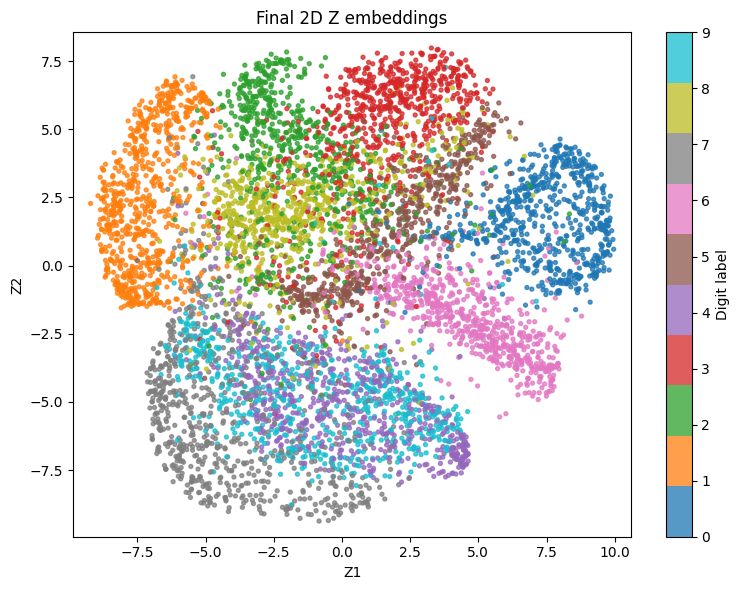

In [8]:
import matplotlib.pyplot as plt

# Visualize final 2D embeddings directly
Z_np = Z.detach().cpu().numpy()

plt.figure(figsize=(8, 6))
if "y" in globals() and y is not None:
    labels = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
    scatter = plt.scatter(
        Z_np[:, 0],
        Z_np[:, 1],
        c=labels,
        cmap="tab10",
        s=8,
        alpha=0.75,
    )
    plt.colorbar(scatter, ticks=range(10), label="Digit label")
else:
    plt.scatter(Z_np[:, 0], Z_np[:, 1], s=8, alpha=0.75)

plt.title("Final 2D Z embeddings")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.axis("equal")
plt.tight_layout()
plt.show()

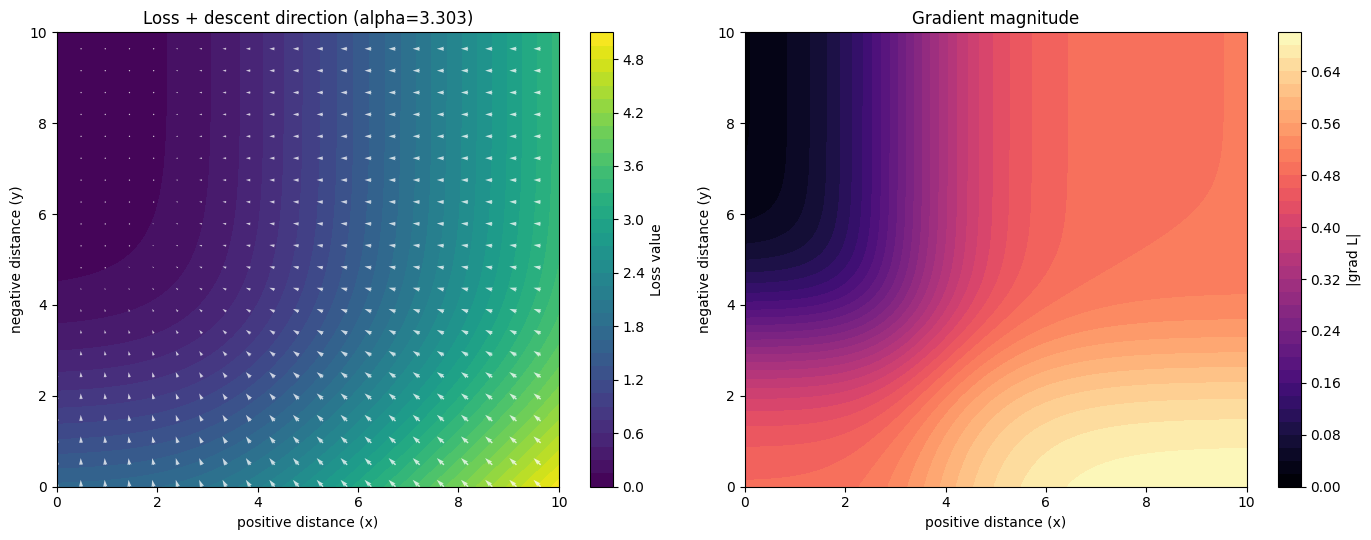

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# x = positive-pair distance, y = negative-pair distance
x = np.linspace(0.0, 10.0, 250)
y = np.linspace(0.0, 10.0, 250)
X, Y = np.meshgrid(x, y)

# Use learned alpha if available; otherwise default to 0
if "alpha" in globals():
    if hasattr(alpha, "detach"):
        alpha_value = float(alpha.detach().cpu().item())
    else:
        alpha_value = float(alpha)
else:
    alpha_value = 0.0

reg_lambda = 1e-4

# Model loss components from training loop:
# pos_loss = softplus(-(alpha - pos_dist))
# neg_loss = softplus(alpha - neg_dist)
# bce_balanced = 0.5 * (pos_loss + neg_loss)
pos_logits = alpha_value - X
neg_logits = alpha_value - Y
pos_loss = np.log1p(np.exp(-pos_logits))
neg_loss = np.log1p(np.exp(neg_logits))
bce_balanced = 0.5 * (pos_loss + neg_loss)

# Approximate regularization effect on two distance axes
reg = reg_lambda * 0.5 * (X**2 + Y**2)
L = bce_balanced + reg

# Gradients: dL/dx and dL/dy
step_x = x[1] - x[0]
step_y = y[1] - y[0]
dL_dy, dL_dx = np.gradient(L, step_y, step_x)
grad_norm = np.sqrt(dL_dx**2 + dL_dy**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: loss surface with gradient descent direction field (-grad)
contour = axes[0].contourf(X, Y, L, levels=40, cmap="viridis")
fig.colorbar(contour, ax=axes[0], label="Loss value")

stride = 12
axes[0].quiver(
    X[::stride, ::stride],
    Y[::stride, ::stride],
    -dL_dx[::stride, ::stride],
    -dL_dy[::stride, ::stride],
    color="white",
    alpha=0.75,
    scale=35,
    width=0.003,
)
axes[0].set_xlabel("positive distance (x)")
axes[0].set_ylabel("negative distance (y)")
axes[0].set_title(f"Loss + descent direction (alpha={alpha_value:.3f})")

# Right: gradient magnitude map
grad_map = axes[1].contourf(X, Y, grad_norm, levels=40, cmap="magma")
fig.colorbar(grad_map, ax=axes[1], label="|grad L|")
axes[1].set_xlabel("positive distance (x)")
axes[1].set_ylabel("negative distance (y)")
axes[1].set_title("Gradient magnitude")

plt.tight_layout()
plt.show()

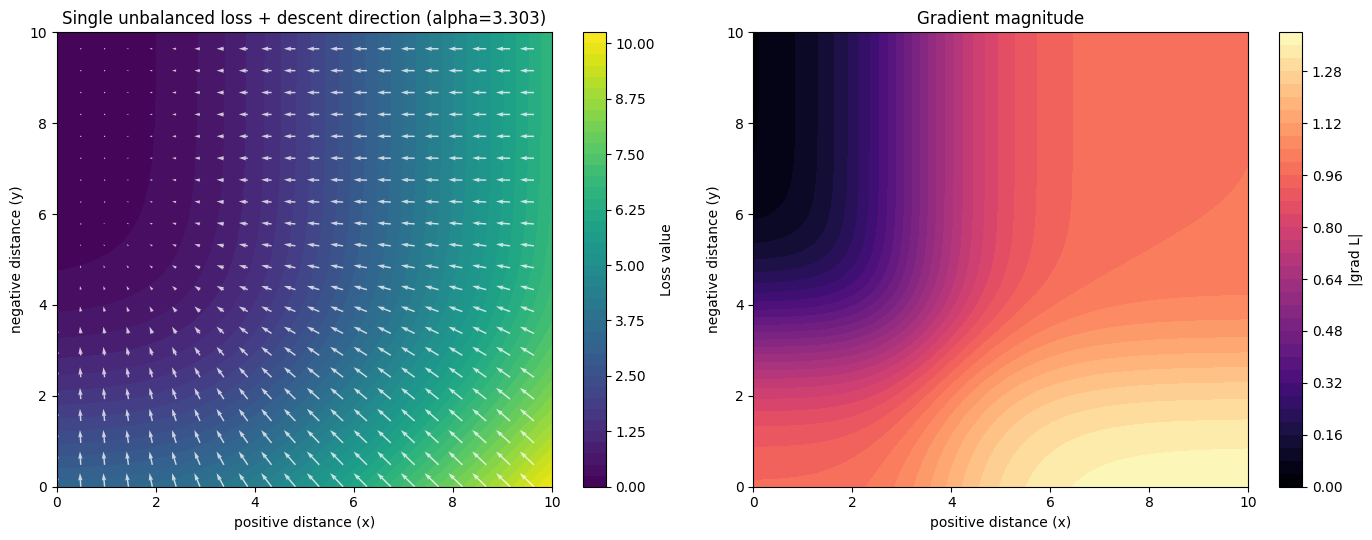

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# x = positive-pair distance, y = negative-pair distance
x = np.linspace(0.0, 10.0, 250)
y = np.linspace(0.0, 10.0, 250)
X, Y = np.meshgrid(x, y)

# Use learned alpha if available; otherwise default to 0
if "alpha" in globals():
    if hasattr(alpha, "detach"):
        alpha_value = float(alpha.detach().cpu().item())
    else:
        alpha_value = float(alpha)
else:
    alpha_value = 0.0

reg_lambda = 1e-4

# Single unbalanced objective (no 0.5 balancing)
# L_data = softplus(-(alpha - pos_dist)) + softplus(alpha - neg_dist)
L_data = np.log1p(np.exp(-(alpha_value - X))) + np.log1p(np.exp(alpha_value - Y))

# Approximate regularization effect on two distance axes
reg = reg_lambda * 0.5 * (X**2 + Y**2)
L = L_data + reg

# Gradients: dL/dx and dL/dy
step_x = x[1] - x[0]
step_y = y[1] - y[0]
dL_dy, dL_dx = np.gradient(L, step_y, step_x)
grad_norm = np.sqrt(dL_dx**2 + dL_dy**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: loss surface with gradient descent direction field (-grad)
contour = axes[0].contourf(X, Y, L, levels=40, cmap="viridis")
fig.colorbar(contour, ax=axes[0], label="Loss value")

stride = 12
axes[0].quiver(
    X[::stride, ::stride],
    Y[::stride, ::stride],
    -dL_dx[::stride, ::stride],
    -dL_dy[::stride, ::stride],
    color="white",
    alpha=0.75,
    scale=35,
    width=0.003,
)
axes[0].set_xlabel("positive distance (x)")
axes[0].set_ylabel("negative distance (y)")
axes[0].set_title(f"Single unbalanced loss + descent direction (alpha={alpha_value:.3f})")

# Right: gradient magnitude map
grad_map = axes[1].contourf(X, Y, grad_norm, levels=40, cmap="magma")
fig.colorbar(grad_map, ax=axes[1], label="|grad L|")
axes[1].set_xlabel("positive distance (x)")
axes[1].set_ylabel("negative distance (y)")
axes[1].set_title("Gradient magnitude")

plt.tight_layout()
plt.show()